In [2]:
# notebooks/eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/telco_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

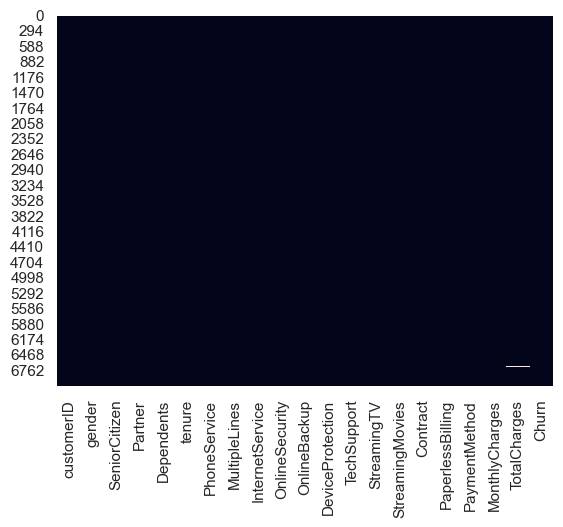

In [7]:
# Visualize missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [8]:
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_2904\3497282575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)


In [9]:
(df["Churn"].value_counts()/len(df))*100
'''
% churn customers 73% no, 27% yes
imbalance observation
'''

'\n% churn customers 73% no, 27% yes\nimbalance observation\n'

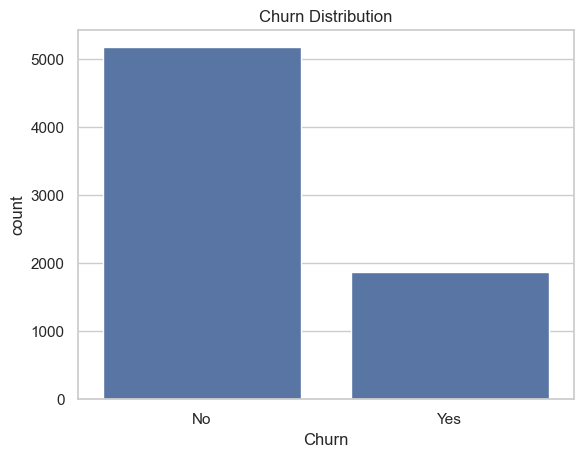

In [10]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

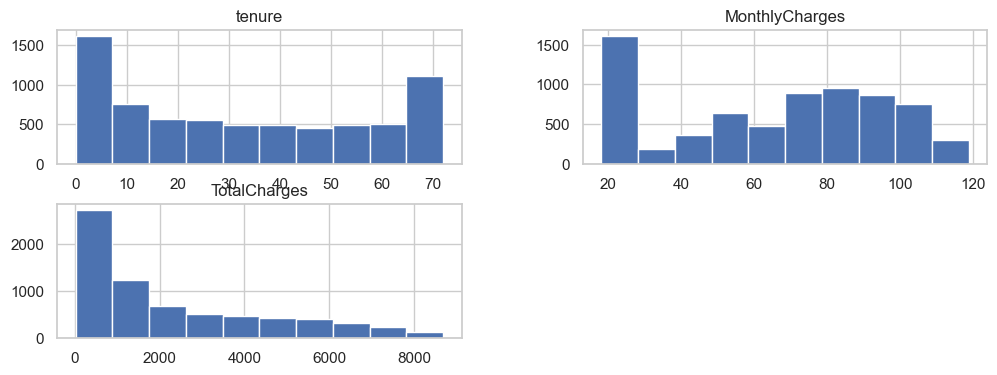

In [11]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].hist(figsize=(12,4))
plt.show()

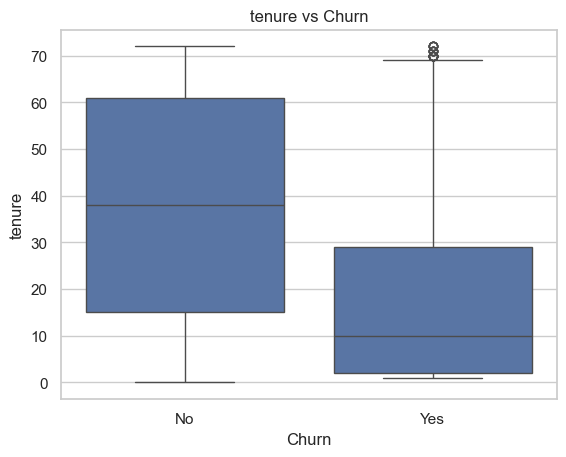

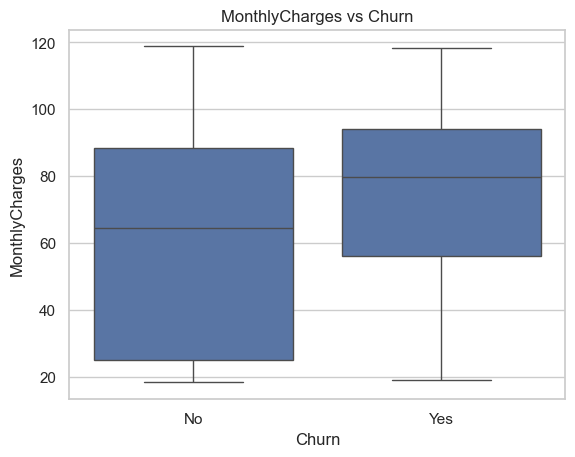

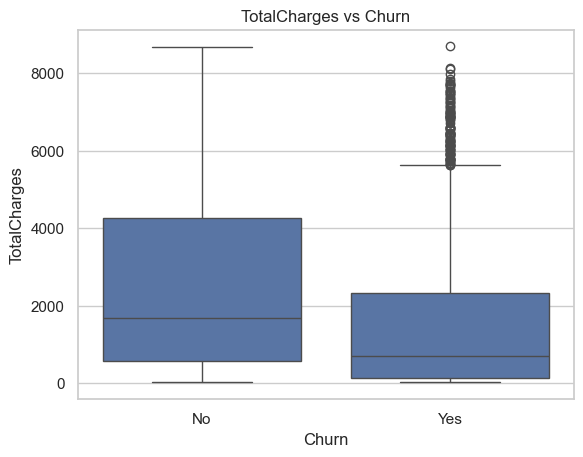

' \nInsights to write:\n\nHigh charges → more churn\nLow tenure → more churn\n'

In [12]:
for col in num_cols:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()
''' 
Insights to write:

High charges → more churn
Low tenure → more churn
'''

In [13]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

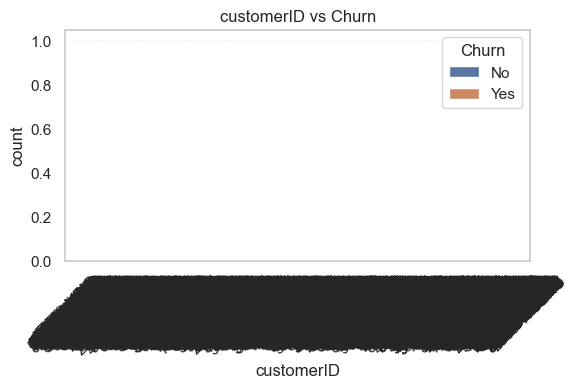

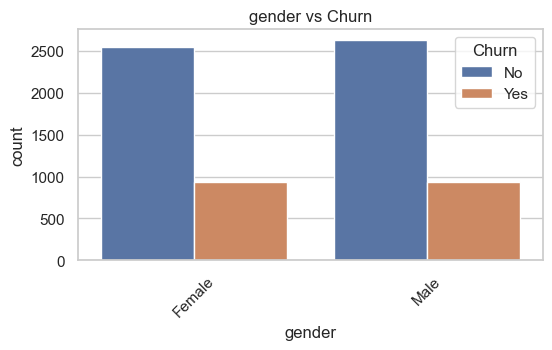

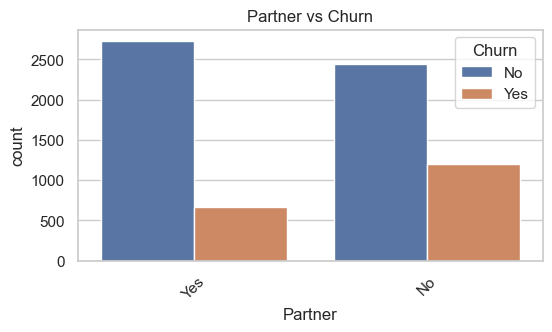

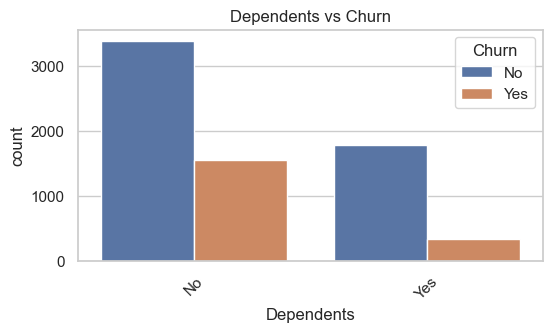

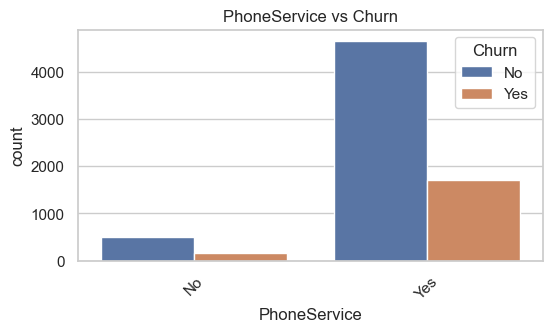

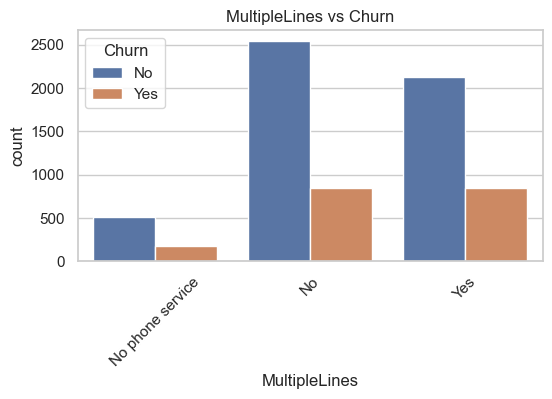

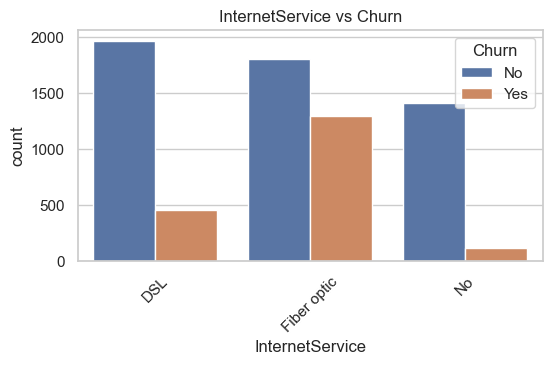

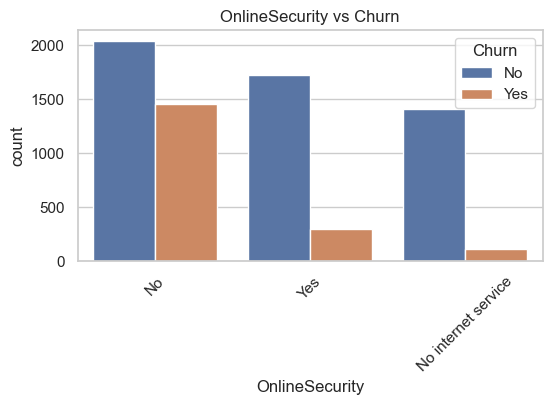

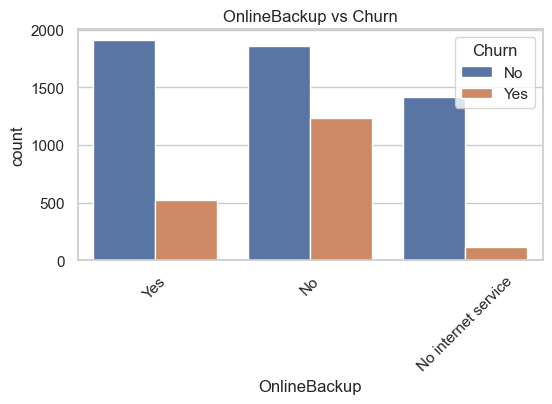

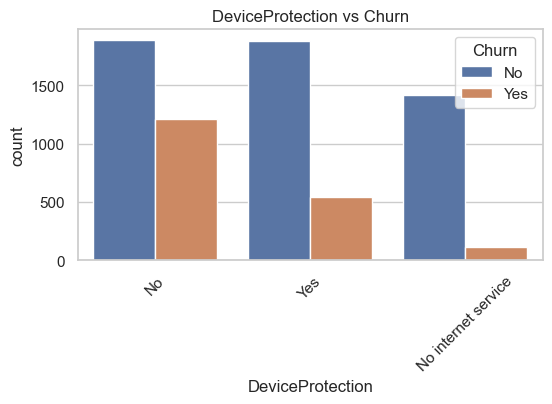

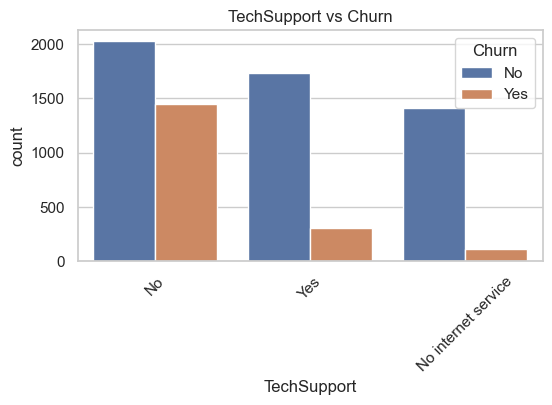

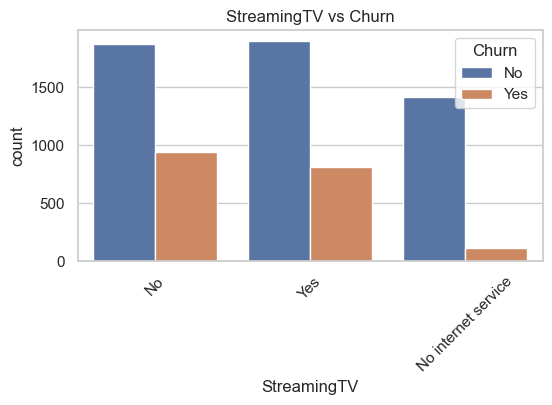

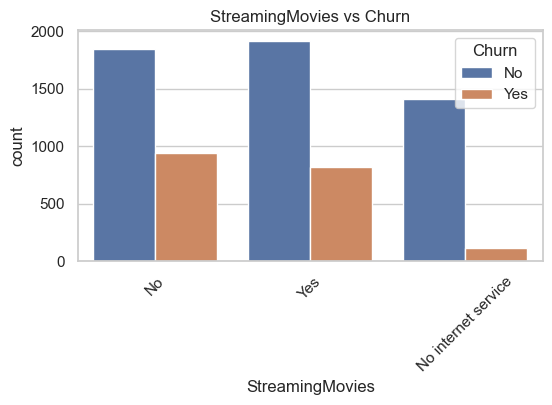

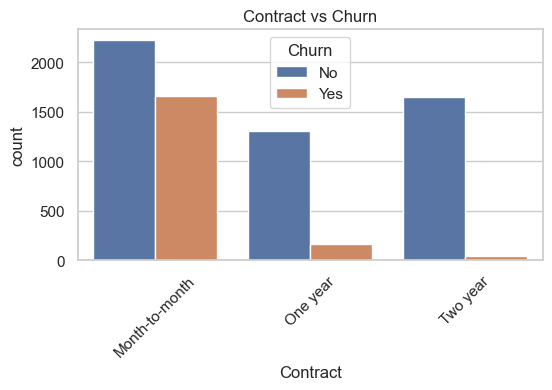

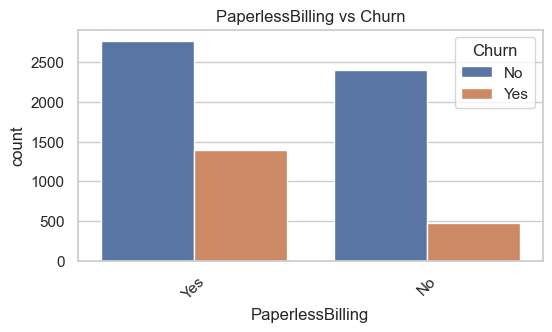

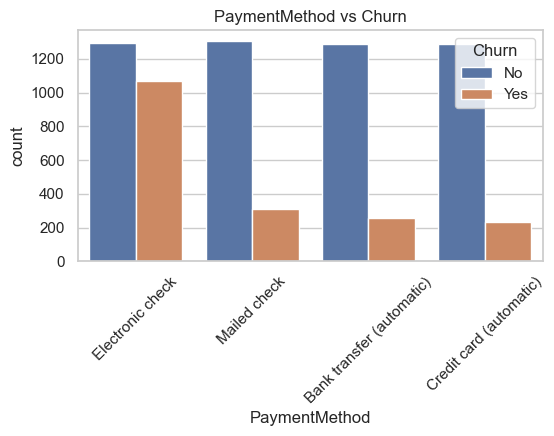

In [14]:
#Identifing top churn drivers
for col in cat_cols:
    if col != "Churn":
        plt.figure(figsize=(6,3))
        sns.countplot(x=col, hue="Churn", data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
        plt.show()

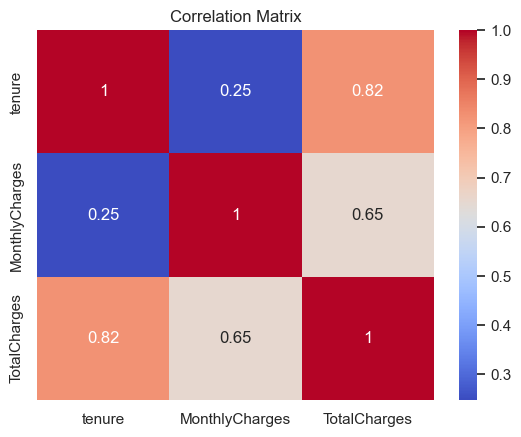

In [15]:
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [16]:
churn_rate = {}

for col in cat_cols:
    if col != "Churn":
        churn_rate[col] = df.groupby(col)["Churn"].apply(lambda x: (x=="Yes").mean())

churn_rate

{'customerID': customerID
 0002-ORFBO    0.0
 0003-MKNFE    0.0
 0004-TLHLJ    1.0
 0011-IGKFF    1.0
 0013-EXCHZ    1.0
              ... 
 9987-LUTYD    0.0
 9992-RRAMN    1.0
 9992-UJOEL    0.0
 9993-LHIEB    0.0
 9995-HOTOH    0.0
 Name: Churn, Length: 7043, dtype: float64,
 'gender': gender
 Female    0.269209
 Male      0.261603
 Name: Churn, dtype: float64,
 'Partner': Partner
 No     0.329580
 Yes    0.196649
 Name: Churn, dtype: float64,
 'Dependents': Dependents
 No     0.312791
 Yes    0.154502
 Name: Churn, dtype: float64,
 'PhoneService': PhoneService
 No     0.249267
 Yes    0.267096
 Name: Churn, dtype: float64,
 'MultipleLines': MultipleLines
 No                  0.250442
 No phone service    0.249267
 Yes                 0.286099
 Name: Churn, dtype: float64,
 'InternetService': InternetService
 DSL            0.189591
 Fiber optic    0.418928
 No             0.074050
 Name: Churn, dtype: float64,
 'OnlineSecurity': OnlineSecurity
 No                     0.417667
 No i

In [17]:
''' 
Top 3 Drivers of Churn:
Month-to-month contracts → highest churn
High MonthlyCharges → higher churn
Low tenure customers → churn early

TOP 3 DRIVERS OF CHURN:

1. Contract Type:
   - Month-to-month customers churn the most
   - Long-term contracts reduce churn

2. Tenure:
   - New customers (low tenure) are more likely to leave

3. Monthly Charges:
   - Higher charges increase churn probability

Business Insight:

- Customers with flexible contracts are not loyal → need retention strategy
- Early-stage customers need onboarding engagement
- High-paying customers need value justification

Action:
- Offer discounts for long-term contracts
- Target new customers within first 3 months
'''
# Numerical
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Categorical
cat_cols = df.select_dtypes(include="object").drop("Churn", axis=1).columns.tolist()

num_cols, cat_cols

(['tenure', 'MonthlyCharges', 'TotalCharges'],
 ['customerID',
  'gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [18]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [19]:
df.to_csv("../data/cleaned_telco.csv", index=False)